# TESS light curves matched to GAOES frames

`../observation_log.csv` の `Frame` をGaia DR3天体に対応させ、各Frameで `science / TESS / SPOC` の先頭1 productだけを使用します。元FITS、正規化CSV、およびTPF・光度曲線・Lomb–Scargle periodogramをまとめた診断図1枚を `tess_lightcurves/<Frame>/` に保存します。取得済みlightcurveをスキップできるため、途中から再開できます。

In [4]:
from pathlib import Path

import pandas as pd
import astropy.units as u
import lightkurve as lk

from tess_lightcurves import build_target_catalog, fetch_all_targets, frame_summary

OBSERVATION_LOG = Path("../observation_log.csv")
ROOT_CANDIDATES = [Path("/mnt6tb/data/analysis_results"), Path("/mnt6tb/data/analysis_result")]
ANALYSIS_ROOT = next((p for p in ROOT_CANDIDATES if p.is_dir()), ROOT_CANDIDATES[0])
MISTFIT_GLOB = "mistfit*"
PREFERRED_MISTFIT = "mistfit_g_st38"
OUTPUT_ROOT = Path("tess_lightcurves")
USE_EXISTING_RESULTS = False  # 既存catalog/manifestを読み、検索・取得を省略
REBUILD_DIAGNOSTICS_FROM_MANIFEST = False  # Trueで既存FITSから4パネル図を再生成
SEARCH_RADIUS = 5 * u.arcsec
AUTHORS = "SPOC"  # science / TESS / SPOC のみに限定
EXPTIME = None  # 例: "short", "fast", 120; None は全 cadence
TPF_CUTOUT_SIZE = 15  # pipeline TPF がない場合の TESScut 一辺 [pixel]
FIGURE_DPI = 160
MAST_TIMEOUT = 60  # 1回のMAST応答待ち上限 [秒]
MAX_TARGETS = None  # 最初の動作確認では 1 などに変更
SKIP_EXISTING_LIGHTCURVES = True  # FITSまたは正規化CSVがあればスキップして途中再開

pd.set_option("display.max_columns", None)
print(f"analysis root: {ANALYSIS_ROOT}")
print(f"output: {OUTPUT_ROOT.resolve()}")

analysis root: /mnt6tb/data/analysis_results
output: /mnt/ogawa/work/rot_evol/lightcurves/tess_lightcurves


## Frame → Gaia DR3

`job_metadata.json` の flat/nested Gaia 情報を読みます。旧 metadata で座標がない場合だけ、同じ MIST fit ディレクトリの `gaia_candidates.csv` を補助的に参照します。異なる MIST fit が別 Gaia source を選んだ Frame は誤マッチを避けて `conflicting_gaia_sources` とし、ダウンロードしません。

In [5]:
TARGET_CATALOG_PATH = OUTPUT_ROOT / "target_catalog.csv"
if USE_EXISTING_RESULTS and TARGET_CATALOG_PATH.is_file():
    targets = pd.read_csv(
        TARGET_CATALOG_PATH,
        dtype={"frame_id": "string", "gaia_source_id": "string"},
    )
    print(f"既存target catalogを読み込みました: {TARGET_CATALOG_PATH}")
else:
    targets = build_target_catalog(
        OBSERVATION_LOG, ANALYSIS_ROOT, OUTPUT_ROOT,
        mistfit_glob=MISTFIT_GLOB, preferred_mistfit=PREFERRED_MISTFIT,
    )
print(targets["local_status"].value_counts(dropna=False))
display(targets.head())

Reading MIST metadata:   0%|          | 0/590 [00:00<?, ?it/s]

local_status
ready    226
Name: count, dtype: int64


,frame_id,frame_norm,object_name,gaia_source_id,gaia_ra_deg,gaia_dec_deg,mistfit_dir,run_status,metadata_path,metadata_mtime,local_status
0,GRA00029409,00029409,G705631,705631623149811712,134.494701,30.233947,mistfit_g_st38,None,/mnt6tb/data/analysis_results/20260310/G705631...,1.784389e+09,ready
1,GRA00029410,00029410,G716109,716109930305855360,132.633925,33.284683,mistfit_g_st38,None,/mnt6tb/data/analysis_results/20260310/G716109...,1.784389e+09,ready
2,GRA00029411,00029411,G718117,718117539756671232,131.042068,36.917984,mistfit_g_st38,None,/mnt6tb/data/analysis_results/20260310/G718117...,1.784389e+09,ready
3,GRA00029412,00029412,G918107,918107434852949888,126.903142,45.651426,mistfit_g_st38,None,/mnt6tb/data/analysis_results/20260310/G918107...,1.784389e+09,ready
4,GRA00029413,00029413,G101622,1016229845380801408,136.327416,50.823482,mistfit_g_st38,None,/mnt6tb/data/analysis_results/20260310/G101622...,1.784389e+09,ready


## TESS 検索・保存

検索結果を `intentType=science`, `obs_collection=TESS`, `provenance_name=SPOC` で絞り、MAST順の先頭1行だけを使用します。同じsectorのTPFと、normalized light curve、Lomb–Scargle periodogramを1枚のPNGに保存します。

In [6]:
MANIFEST_PATH = OUTPUT_ROOT / "manifest.csv"
if USE_EXISTING_RESULTS and MANIFEST_PATH.is_file():
    manifest = pd.read_csv(
        MANIFEST_PATH,
        dtype={"frame_id": "string", "gaia_source_id": "string"},
    )
    print(f"既存manifestを読み込みました: {MANIFEST_PATH}")
else:
    manifest = fetch_all_targets(
        targets, OUTPUT_ROOT, search_radius=SEARCH_RADIUS, authors=AUTHORS,
        exptime=EXPTIME, tpf_cutout_size=TPF_CUTOUT_SIZE,
        figure_dpi=FIGURE_DPI, mast_timeout=MAST_TIMEOUT,
        max_targets=MAX_TARGETS,
        skip_existing_lightcurves=SKIP_EXISTING_LIGHTCURVES,
    )
print(manifest["status"].value_counts(dropna=False) if not manifest.empty else "manifest is empty")
if REBUILD_DIAGNOSTICS_FROM_MANIFEST:
    from tess_variability import rebuild_diagnostic_figures
    diagnostic_updates = rebuild_diagnostic_figures(
        manifest, OUTPUT_ROOT, dpi=FIGURE_DPI, overwrite=True,
    )
    print(diagnostic_updates["diagnostic_status"].value_counts(dropna=False))
display(manifest.tail())

TESS targets:   0%|          | 0/19 [00:00<?, ?it/s]

No data found for target "<SkyCoord (ICRS): (ra, dec) in deg
    (291.35645874, 24.90997127)>".
No data found for target "<SkyCoord (ICRS): (ra, dec) in deg
    (157.01673062, 48.78098697)>".
No data found for target "<SkyCoord (ICRS): (ra, dec) in deg
    (258.22651097, 0.35170546)>".
No data found for target "<SkyCoord (ICRS): (ra, dec) in deg
    (252.59272938, -2.65456027)>".
No data found for target "<SkyCoord (ICRS): (ra, dec) in deg
    (250.0073253, -6.08169357)>".
No data found for target "<SkyCoord (ICRS): (ra, dec) in deg
    (261.49141717, -1.65155328)>".
No data found for target "<SkyCoord (ICRS): (ra, dec) in deg
    (221.18715638, -9.7042752)>".
No data found for target "<SkyCoord (ICRS): (ra, dec) in deg
    (235.75785685, -10.93484806)>".
No data found for target "<SkyCoord (ICRS): (ra, dec) in deg
    (240.42126498, -3.7633049)>".
No data found for target "<SkyCoord (ICRS): (ra, dec) in deg
    (241.12331551, 0.67186225)>".
No data found for target "<SkyCoord (ICRS): 

status
saved                     261
search_columns_missing     18
download_error              5
Name: count, dtype: int64


,frame_id,frame_norm,object_name,gaia_source_id,gaia_ra_deg,gaia_dec_deg,metadata_path,status,n_search_results,error,search_result_index,mission,sector,author,targetid,n_cadences,fits_path,normalized_csv_path,tpf_status,tpf_path,tpf_error,diagnostic_figure_path,best_lombscargle_period_day,figure_error
279,GRA00029748,00029748,G361557,3615575354641355776,208.971346,-9.755230,/mnt6tb/data/analysis_results/20260314/G361557...,search_columns_missing,NaN,"Missing MAST columns: ['intentType', 'obs_coll...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
280,GRA00029750,00029750,G631328,6313286747536128128,222.650571,-12.018295,/mnt6tb/data/analysis_results/20260314/G631328...,search_columns_missing,NaN,"Missing MAST columns: ['intentType', 'obs_coll...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
281,GRA00029751,00029751,G439888,4398887092042905856,240.421265,-3.763305,/mnt6tb/data/analysis_results/20260314/G439888...,search_columns_missing,NaN,"Missing MAST columns: ['intentType', 'obs_coll...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
282,GRA00029752,00029752,G435092,4350921790633365760,247.203738,-8.129152,/mnt6tb/data/analysis_results/20260314/G435092...,search_columns_missing,NaN,"Missing MAST columns: ['intentType', 'obs_coll...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
283,GRA00031160,00031160,G440705,4407056807034649472,244.081132,-1.648001,/mnt6tb/data/analysis_results/20260505/G440705...,search_columns_missing,NaN,"Missing MAST columns: ['intentType', 'obs_coll...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Frame 対応表と light curve の確認

,frame_id,object_name,gaia_source_id,local_status,tess_products,tess_status
0,GRA00029409,G705631,705631623149811712,ready,6.0,download_error;saved
1,GRA00029410,G716109,716109930305855360,ready,1.0,saved
2,GRA00029411,G718117,718117539756671232,ready,2.0,saved
3,GRA00029412,G918107,918107434852949888,ready,3.0,saved
4,GRA00029413,G101622,1016229845380801408,ready,2.0,saved
...,...,...,...,...,...,...
221,GRA00031183,G181424,1814241194252808704,ready,1.0,saved
222,GRA00031184,G176031,1760316677257596288,ready,1.0,saved
223,GRA00031185,G178923,1789231256087445120,ready,1.0,saved
224,GRA00031186,G178541,1785414129672353408,ready,1.0,saved


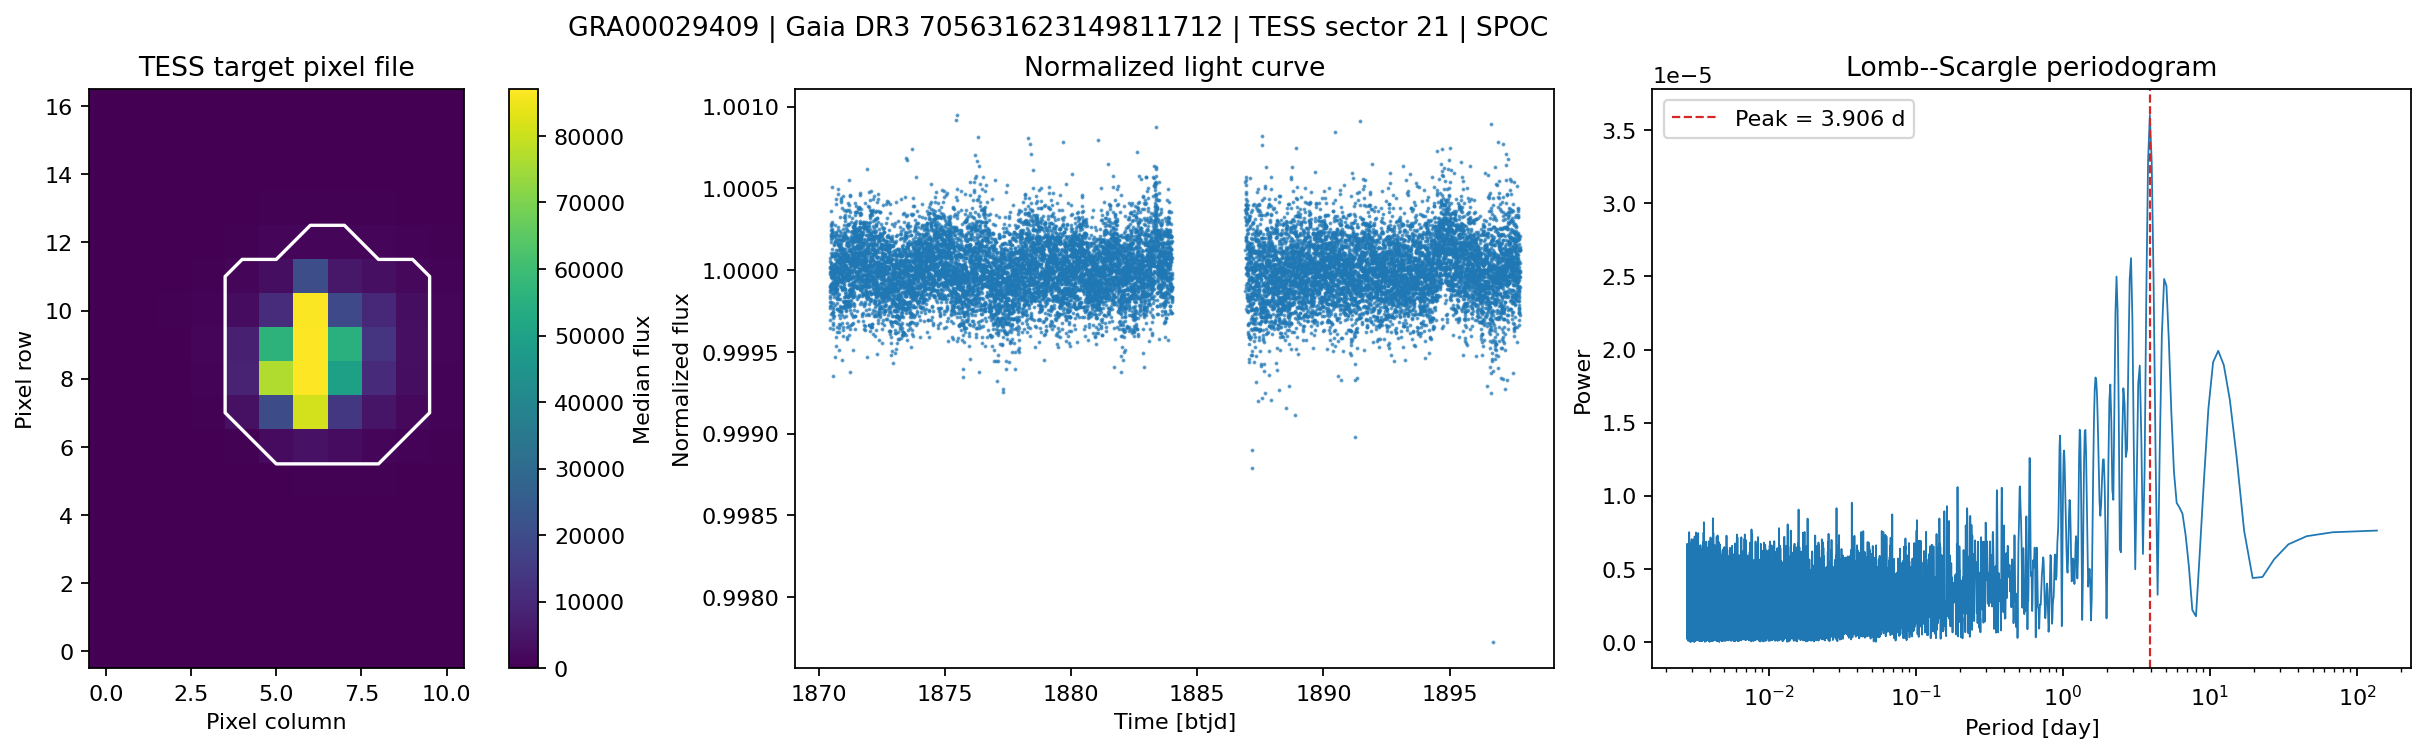

In [7]:
summary = frame_summary(targets, manifest, OUTPUT_ROOT)
display(summary)

saved = manifest.loc[manifest["status"].eq("saved")] if not manifest.empty else pd.DataFrame()
if not saved.empty:
    example = saved.iloc[0]
    from IPython.display import Image
    display(Image(filename=example["diagnostic_figure_path"]))
else:
    print("保存済み light curve はまだありません。")

## 食候補と明瞭な自転変動の抽出

保存済みFITSからFrameごとに1本のlightcurveを選びます。食候補はBLSのS/N・深さ・duty cycle・下側裾の非対称性で抽出します。自転候補はLomb–ScargleのFAPに加え、位相折り畳みの整合度と振幅S/Nを要求します。以下の閾値は候補選定用であり、食候補は最終的に診断図や位相曲線で確認してください。

In [8]:
import sys

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))  # ../rot_evol を利用

from tess_variability import (
    analyze_saved_lightcurves,
    load_stellar_rotation_parameters,
    save_rotation_comparison,
)

ECLIPSE_SNR_THRESHOLD = 12.0
ECLIPSE_MIN_DEPTH = 0.001
ECLIPSE_MAX_SINUSOID_R2 = 0.5  # 滑らかな正弦波状変動を食から除外
ROTATION_FAP_THRESHOLD = 1e-5
ROTATION_COHERENCE_THRESHOLD = 0.20
ROTATION_AMPLITUDE_SNR_THRESHOLD = 1.5

In [9]:
variability = analyze_saved_lightcurves(
    manifest, OUTPUT_ROOT,
    eclipse_snr_threshold=ECLIPSE_SNR_THRESHOLD,
    eclipse_min_depth=ECLIPSE_MIN_DEPTH,
    eclipse_max_sinusoid_r2=ECLIPSE_MAX_SINUSOID_R2,
    rotation_fap_threshold=ROTATION_FAP_THRESHOLD,
    rotation_coherence_threshold=ROTATION_COHERENCE_THRESHOLD,
    rotation_amplitude_snr_threshold=ROTATION_AMPLITUDE_SNR_THRESHOLD,
)
variability.to_csv(OUTPUT_ROOT / "variability_metrics.csv", index=False)

eclipse_candidates = (
    variability.loc[variability["eclipse_candidate"].fillna(False)]
    .sort_values("bls_snr", ascending=False)
    .reset_index(drop=True)
)
eclipse_candidates.to_csv(OUTPUT_ROOT / "eclipse_candidates.csv", index=False)
print(f"食候補: {len(eclipse_candidates)} / {len(variability)} stars")
display(eclipse_candidates[[
    "frame_id", "object_name", "sector", "bls_period_day",
    "bls_depth", "bls_snr", "bls_duty_cycle", "dip_asymmetry", "sinusoid_r2",
]])

TESS variability:   0%|          | 0/203 [00:00<?, ?frame/s]

食候補: 4 / 203 stars


,frame_id,object_name,sector,bls_period_day,bls_depth,bls_snr,bls_duty_cycle,dip_asymmetry,sinusoid_r2
0,GRA00029523,G631740,51.0,7.965785,0.016252,151.487771,0.015064,1.248086,0.091807
1,GRA00031187,G178406,55.0,4.395496,0.001109,136.394012,0.027301,1.386964,0.242411
2,GRA00029815,G150606,16.0,2.978427,0.001320,115.861546,0.040290,1.166751,0.475239
3,GRA00029647,G367561,46.0,7.822704,0.001151,73.185007,0.015340,1.370549,0.144841


## $P_{\rm rot}$ と $2\pi R/(v\sin i)$ の比較

`R` と `v sin i` は `../rot_evol` と同じ解析結果ローダーから取得します。`2πR/(v sin i)` は真の自転周期の上限なので、整合する星は原理的に等値線上またはその上側に位置します。食候補はこの比較から除外します。

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


R and v sin(i):   0%|          | 0/21 [00:00<?, ?frame/s]

,frame_id,object_name,p_rot_day,radius_rsun,vsini_km_s,p_2piR_vsini_day,p_rot_over_p_2piR_vsini
1,GRA00029410,G716109,3.744022,1.208398,8.763808,6.975981,0.536702
18,GRA00029427,G352836,3.426570,1.040515,7.124661,7.388773,0.463754
53,GRA00029498,G156622,6.082947,0.957712,7.426848,6.524069,0.932385
57,GRA00029503,G155871,4.424159,1.086813,12.131428,4.532430,0.976112
61,GRA00029508,G761919,6.710383,1.016420,5.603635,9.176802,0.731233
65,GRA00029513,G132886,1.154616,0.961456,0.708003,68.704095,0.016806
68,GRA00029516,G229276,5.198111,1.951401,19.885413,4.964780,1.046997
73,GRA00029524,G440045,5.854303,1.056450,8.674336,6.161703,0.950111
87,GRA00029582,G352836,1.674216,1.049842,7.011029,7.575834,0.220994
90,GRA00029585,G125205,1.308223,1.279752,37.652614,1.719566,0.760787


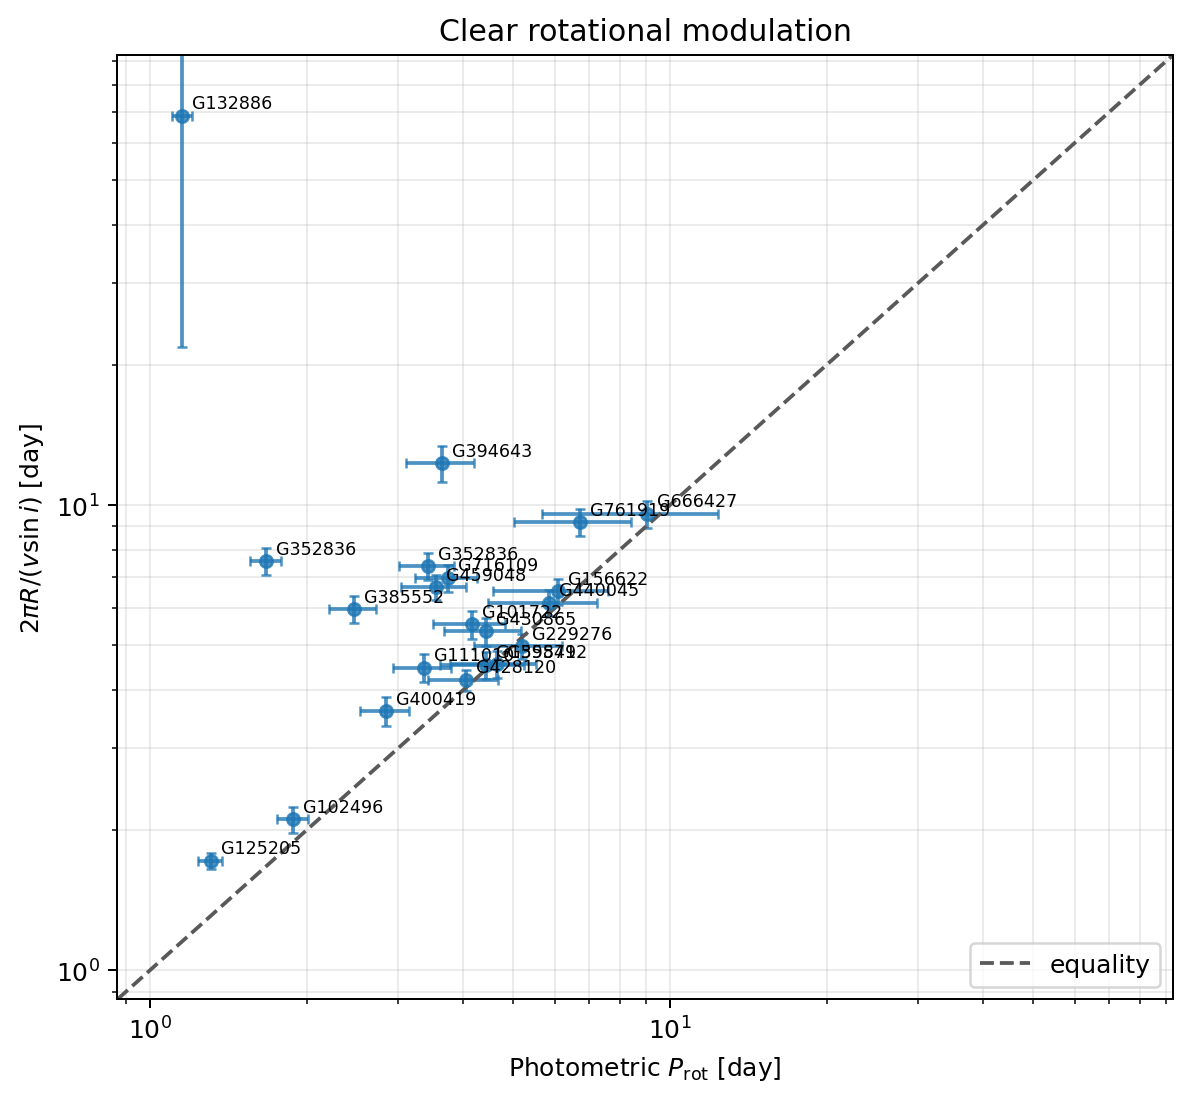

In [10]:
clear_rotators = variability.loc[
    variability["clear_rotation"].fillna(False)
    & ~variability["eclipse_candidate"].fillna(False)
].copy()
stellar_rotation = load_stellar_rotation_parameters(
    clear_rotators["frame_id"].tolist(),
    analysis_root=ANALYSIS_ROOT,
    spec_label="orders03-08",
    iso_label=PREFERRED_MISTFIT,
)
rotation_comparison, rotation_figure_path = save_rotation_comparison(
    variability, stellar_rotation,
    OUTPUT_ROOT / "p_rot_vs_2piR_vsini.png",
)
rotation_comparison.to_csv(OUTPUT_ROOT / "rotation_period_comparison.csv", index=False)

display(rotation_comparison[[
    "frame_id", "object_name", "p_rot_day", "radius_rsun",
    "vsini_km_s", "p_2piR_vsini_day", "p_rot_over_p_2piR_vsini",
]])
from IPython.display import Image
display(Image(filename=str(rotation_figure_path)))